# Распознавание рукописных цифр методом опорных векторов (SVM)

## Домашнее задание 1

**Цель работы:** Обучить модель SVM на датасете MNIST, сохранить данные в БД, протестировать на реальных картинках и развернуть веб-сервер.

## 1. Импорт необходимых библиотек

In [1]:
# Импорты
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import os
from PIL import Image, ImageOps
import glob

## 2. Загрузка данных из базы

In [2]:
# Путь к базе (поднимаемся из папки notebooks в корень проекта)
DB_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'mnist.db')

# Подключаемся и читаем данные
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM mnist_data", conn)
conn.close()

# Извлекаем признаки и метки
X = df.iloc[:, 1:-1].values  # все пиксели
y = df.iloc[:, -1].values     # метки

# Нормализация
X = X / 255.0

print(f"✅ Загружено {X.shape[0]} изображений")
print(f"   Размер X: {X.shape}")
print(f"   Размер y: {y.shape}")
print(f"   Пиксели: от {X.min():.2f} до {X.max():.2f}")

✅ Загружено 70000 изображений
   Размер X: (70000, 784)
   Размер y: (70000,)
   Пиксели: от 0.00 до 1.00


## 3. Разделение на обучающую и тестовую выборки

In [3]:
# Константы
TEST_SIZE = 0.15  # 15% данных оставим для теста
RANDOM_STATE = 42  # для воспроизводимости

# # Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # сохраняем пропорции цифр
)

print(f"Обучающая выборка: {X_train.shape[0]} картинок")
print(f"Тестовая выборка: {X_test.shape[0]} картинок")

Обучающая выборка: 59500 картинок
Тестовая выборка: 10500 картинок


## 4. Обучение модели SVM

In [4]:
# Создаём и обучаем модель
model = SVC(kernel='rbf', gamma='scale', verbose=True)
model.fit(X_train, y_train)

print("✅ Модель обучена")

[LibSVM]✅ Модель обучена


## 5. Оценка качества модели

In [5]:
# Предсказания на тестовых данных
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f} ({accuracy*100:.1f}%)")

Точность модели: 0.9810 (98.1%)


## 6. Матрица ошибок

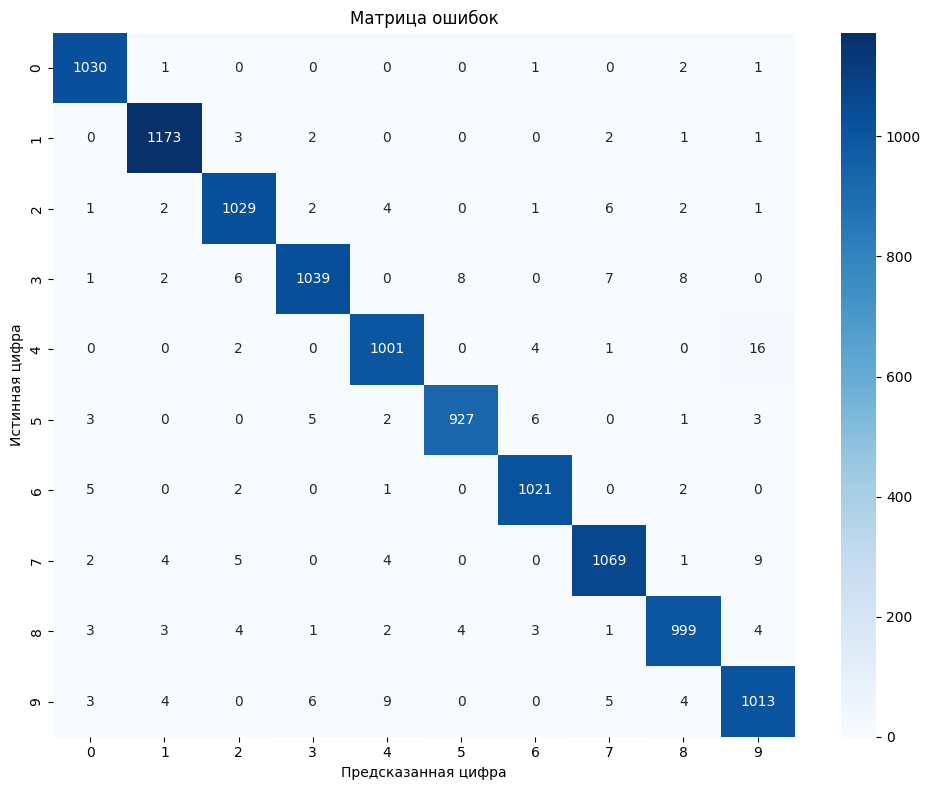

In [6]:
# Построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

## 7. Примеры цифр из тестовой выборки (по одной каждого класса)

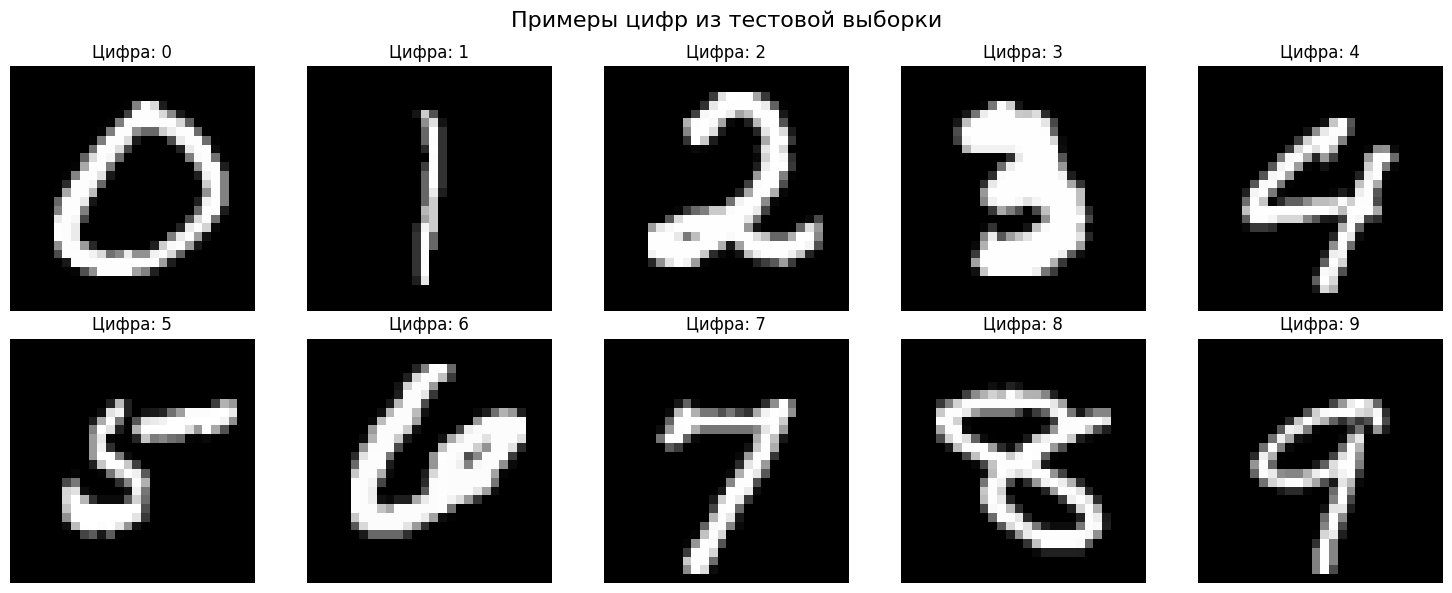

In [7]:
# Примеры цифр из тестовой выборки
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y_test == i)[0][0]
    img = X_test[idx].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Цифра: {i}')
    axes[i].axis('off')

plt.suptitle('Примеры цифр из тестовой выборки', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Случайные картинки с предсказаниями

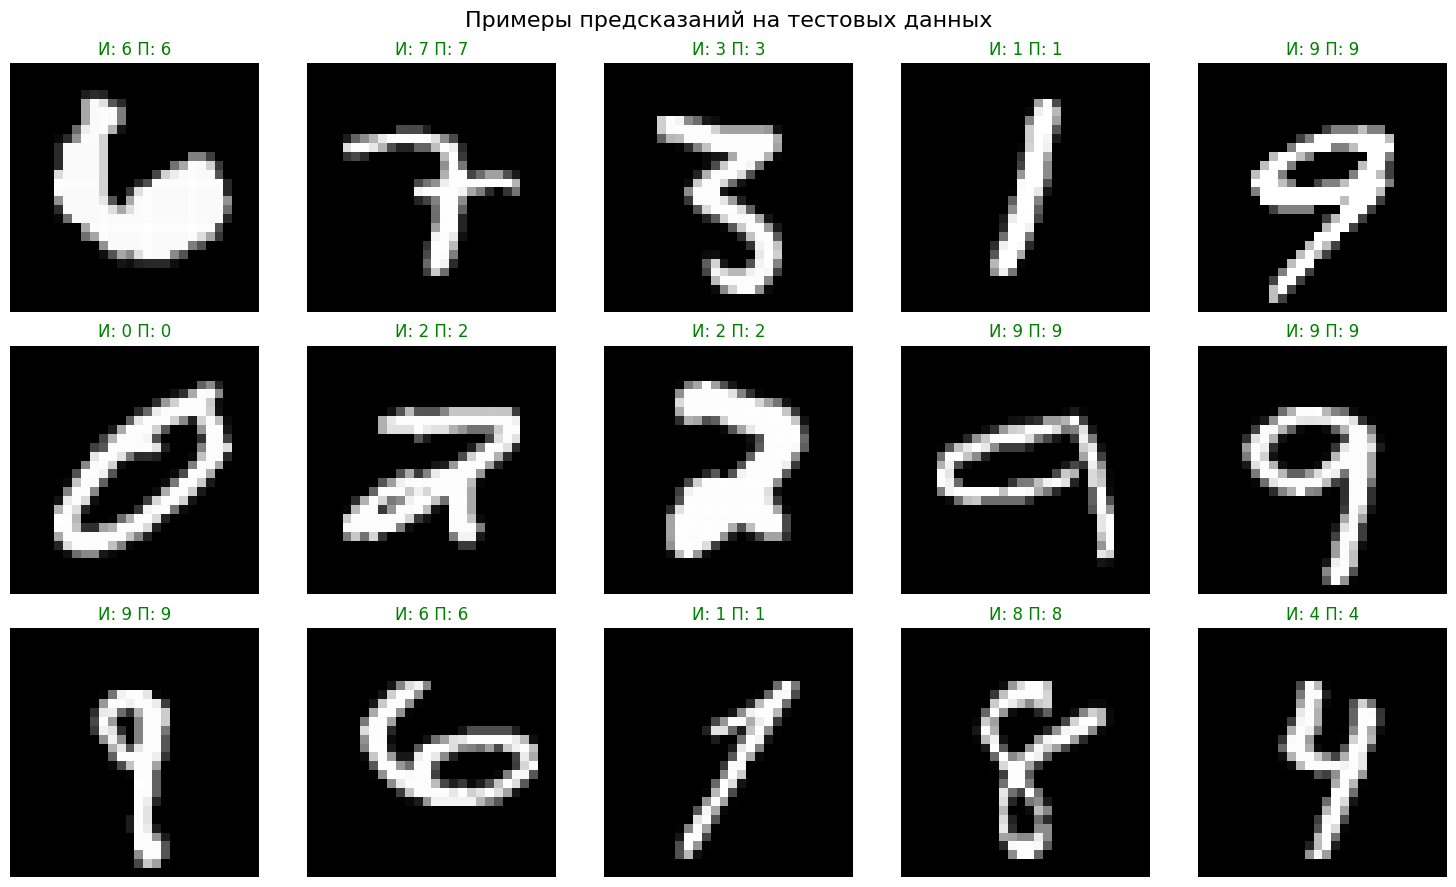

In [8]:
# Покажем несколько примеров цифр с предсказаниями
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

# Берём случайные индексы
np.random.seed(42)
indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(indices):
    img = X_test[idx].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    # Зелёный если угадала, красный если ошиблась
    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    axes[i].set_title(f'И: {y_test[idx]} П: {y_pred[idx]}', color=color)
    axes[i].axis('off')

plt.suptitle('Примеры предсказаний на тестовых данных', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Тестирование на реальных картинках 

In [9]:
# # Папка с тестовыми картинками (поднимаемся из папки notebooks)
TEST_IMAGES_DIR = os.path.join(os.path.dirname(os.getcwd()), 'test_images')

# Функция подготовки изображения
def prepare_image(image_path):
    """
    Подготавливает картинку для модели:
    - ч/б
    - размер 28x28
    - превращает в массив 784 чисел
    - нормализует
    """
    # Открываем картинку
    img = Image.open(image_path)
    img_original = img.copy()  # сохраняем оригинал для показа

    # Превращаем в ч/б
    img = img.convert('L')

    # Меняем размер на 28x28
    img = img.resize((28, 28))

    # Превращаем в массив numpy
    img_array = np.array(img)

    # Автоматическая инверсия: делаем так, чтобы цифра была светлее фона
    # Модель обучена на белых цифрах на чёрном фоне
    if np.mean(img_array) > 127:  # если фон светлый
        img_array = 255 - img_array  # инвертируем в тёмный фон, светлую цифру

    # Превращаем в плоский массив из 784 чисел
    img_flat = img_array.reshape(784)

    # Нормализуем
    img_normalized = img_flat / 255.0

    return img_normalized, img_original


# Функция предсказания для одной картинки
def predict_single(model, image_array):
    """Принимает модель и массив из 784 чисел, возвращает предсказанную цифру."""
    prediction = model.predict([image_array])[0]
    return prediction


# Ищем все картинки в папке test_images
image_files = glob.glob(os.path.join(TEST_IMAGES_DIR, '*.png')) + \
              glob.glob(os.path.join(TEST_IMAGES_DIR, '*.jpg'))

if not image_files:
    print(f"В папке {TEST_IMAGES_DIR} нет PNG или JPG файлов")
    print("Создай папку и добавь туда картинки с цифрами")
else:
    print(f"Найдено картинок: {len(image_files)}")

Найдено картинок: 20


In [10]:
# Собираем результаты
results = []
for img_file in image_files:
    img_array, img_original = prepare_image(img_file)
    pred = predict_single(model, img_array)

    # Пытаемся извлечь истинную цифру из имени файла
    name = os.path.basename(img_file)
    true_label = None
    digits = [int(c) for c in name if c.isdigit()]
    if digits:
        true_label = digits[0]

    results.append((img_original, pred, true_label, img_file))

# Итоговая статистика
correct = sum(1 for _, pred, true, _ in results if true is not None and pred == true)
total_with_true = sum(1 for _, _, true, _ in results if true is not None)
if total_with_true > 0:
    accuracy = (correct / total_with_true * 100) if total_with_true > 0 else 0
    print(f"Точность на {total_with_true} картинках: {correct}/{total_with_true} = {accuracy:.1f}%")

Точность на 20 картинках: 18/20 = 90.0%


## 10. Визуализация результатов на реальных картинках


Отображаем результаты...


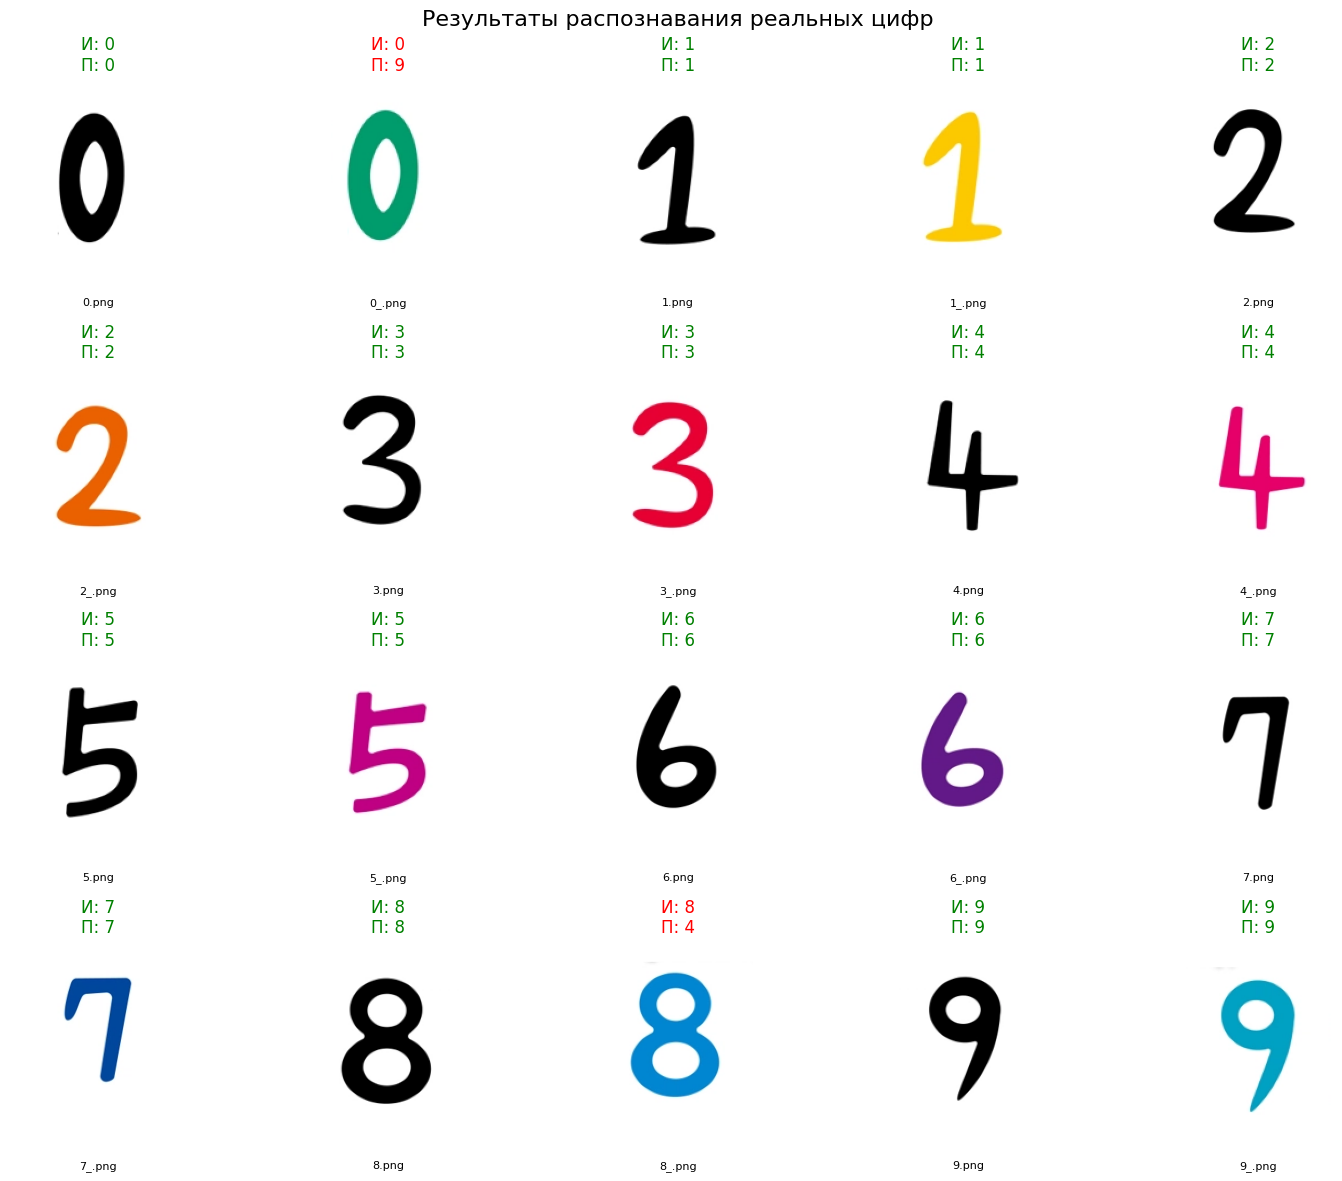


Готово!


In [11]:
# Визуализация результатов
print("\nОтображаем результаты...")

n_images = len(results)
cols = 5
rows = (n_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten() if rows > 1 or cols > 1 else [axes]

for i, (img, pred, true_label, img_file) in enumerate(results):
    # Показываем картинку
    axes[i].imshow(img, cmap='gray')

    # Определяем цвет и текст
    if true_label is not None:
        color = 'green' if pred == true_label else 'red'
        title = f'И: {true_label}\nП: {pred}'
    else:
        color = 'black'
        title = f'Пред: {pred}'

    axes[i].set_title(title, color=color, fontsize=12)
    axes[i].axis('off')

    # Имя файла мелко внизу
    axes[i].text(0.5, -0.1, os.path.basename(img_file),
                 transform=axes[i].transAxes, fontsize=8, ha='center')

# Прячем лишние оси
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Результаты распознавания реальных цифр', fontsize=16)
plt.tight_layout()
plt.show()

print("\nГотово!")

## 11. Веб-сервер

Для использования модели создан веб-сервер на FastAPI с эндпоинтом `/predict`.  <br>
Запуск сервера: `uvicorn src.app:app --reload`  <br>
Документация доступна по адресу `http://127.0.0.1:8000/docs`  <br>

## 12. Выводы по работе

В ходе выполнения работы:

1. ✅ Загружен датасет MNIST и создана база данных `mnist.db` с 70000 изображениями в папке `data/`
2. ✅ Модель SVM (метод опорных векторов) обучена распознавать цифры
3. ✅ На тестовых данных (которые модель не видела, 15% от всех данных) точность составила **98.1%** — это очень хороший результат
4. ✅ Построена матрица ошибок — модель лучше всего распознаёт цифры 0 и 1, иногда путает 4 и 9
5. ✅ Проведено тестирование на реальных картинках из интернета (20 изображений) — результаты оказались хуже, чем на эталонных данных
6. ✅ Замечено, что цветные цифры (не чёрные) распознаются хуже, так как модель обучалась на чёрно-белых изображениях
7. ✅ Создан веб-сервер (файл `src/app.py`), куда можно загрузить картинку и получить предсказание

### Структура проекта:
- `src/` — исходный код (prepare_data.py, train_model.py, predict.py, app.py)
- `data/` — база данных mnist.db
- `models/` — сохранённая модель svm_mnist.pkl
- `test_images/` — тестовые картинки из интернета
- `notebooks/` — Jupyter ноутбук с отчётом

### Что можно улучшить:
- Лучше обрабатывать картинки (обрезать лишнее, центрировать цифру)
- Попробовать нейросеть — она обычно даёт точность выше
- Добавить в обучение реальные картинки, а не только идеальные из MNIST
- Добавить в обучение искажённые копии картинок (чуть повёрнутые, чуть сдвинутые), чтобы модель училась на разных вариантах написания цифр

**Итог:** Модель отлично работает на идеальных картинках (98.1%), но на реальных фотографиях ошибается чаще. Для настоящего приложения нужно дорабатывать обработку картинок или брать нейросеть.